In [ ]:
!pip install qiskit
import os
import librosa
import librosa.display
!pip install pennylane
import matplotlib.pyplot as plt
from pennylane import numpy as np
from scipy.io import wavfile
import warnings
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import RMSprop, SGD
## Local Definition
import sys
sys.path.append('/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/')
from data_generator import gen_mel
from models import cnn_Model, dense_Model, attrnn_Model
from helper_q_tool import gen_qspeech, plot_acc_loss, show_speech
import argparse
os.environ["CUDA_VISIBLE_DEVICES"]="1"
import time as ti
data_ix = ti.strftime("%m%d_%H%M")

labels = [
    'hello', 'field', 'fly', 'crop', 'search', 'patch', 'tree', 'bush', 'forward', 'plant'
]

train_audio_path = 'content/drive/MyDrive/AudioFiles'
SAVE_PATH = "/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/" # Data saving folder

parser = argparse.ArgumentParser()
parser.add_argument("--eps", type=int, default=30, help="Epochs")
parser.add_argument("--bsize", type=int, default=16, help="Batch Size")
parser.add_argument("--sr", type=int, default=16000, help="Sampling Rate for input Speech")
parser.add_argument("--net", type=int, default=1, help="(0) Dense Model, (1) U-Net RNN Attention, (2) CNN Model")
parser.add_argument("--mel", type=int, default=0, help="(0) Load Demo Features, (1) Extra Mel Features")
parser.add_argument("--quanv", type=int, default=0, help="(0) Load Demo Features, (1) Extra Mel Features")
parser.add_argument("--port", type=int, default=100, help="(1/N) data ratio for encoding")
args = parser.parse_args(args=[])

def gen_train(labels, train_audio_path, sr, port):
    all_wave, all_label = gen_mel(labels, train_audio_path, sr, port)

    label_enconder = LabelEncoder()
    y = label_enconder.fit_transform(all_label)
    classes = list(label_enconder.classes_)
    y = keras.utils.to_categorical(y, num_classes=len(labels))

    from sklearn.model_selection import train_test_split
    x_train, x_valid, y_train, y_valid = train_test_split(np.array(all_wave),np.array(y),stratify=y,test_size = 0.2,random_state=777,shuffle=True)
    h_feat, w_feat, _ = x_train[0].shape
    np.save(SAVE_PATH + "n_x_train_speech.npy", x_train)
    np.save(SAVE_PATH + "n_x_test_speech.npy", x_valid)
    np.save(SAVE_PATH + "n_y_train_speech.npy", y_train)
    np.save(SAVE_PATH + "n_y_test_speech.npy", y_valid)
    print("===== Shape", h_feat, w_feat)

    return x_train, x_valid, y_train, y_valid

def gen_quanv(x_train, x_valid, kr):
    print("Kernal = ", kr)
    q_train, q_valid = gen_qspeech(x_train, x_valid, kr)

    np.save(SAVE_PATH + "demo_t1.npy", q_train)
    np.save(SAVE_PATH + "demo_t2.npy", q_valid)

    return q_train, q_valid

if args.mel == 1:
    x_train, x_valid, y_train, y_valid = gen_train(labels, train_audio_path, args.sr, args.port)
else:
    x_train = np.load(SAVE_PATH + "x_train_demo.npy")
    x_valid = np.load(SAVE_PATH + "x_test_demo.npy")
    y_train = np.load(SAVE_PATH + "y_train_demo.npy")
    y_valid = np.load(SAVE_PATH + "y_test_demo.npy")


if args.quanv == 1:
    q_train, q_valid = gen_quanv(x_train, x_valid, 2)
else:
    q_train = np.load(SAVE_PATH + "q_train_demo.npy")
    q_valid = np.load(SAVE_PATH + "q_test_demo.npy")

## For Quanv Exp.
early_stop = EarlyStopping(monitor='val_loss', mode='min',
                           verbose=1, patience=10, min_delta=0.0001)

checkpoint = ModelCheckpoint('checkpoints/best_demo.keras', monitor='val_acc',
                             verbose=1, save_best_only=True, mode='max')


if args.net == 0:
    model = dense_Model(x_train[0], labels)
elif args.net == 1:
    model = attrnn_Model(q_train[0], labels)

model.summary()

history = model.fit(
    x=q_train,
    y=y_train,
    epochs=args.eps,
    callbacks=[checkpoint],
    batch_size=args.bsize,
    validation_data=(q_valid,y_valid)
)


model.save('checkpoints/'+ data_ix + '_demo.hdf5')

print("=== Batch Size: ", args.bsize)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 63.3 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 30, 63, 4)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 30, 63, 4)      │             16 │ input_layer_1[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ permute (Permute)         │ (None, 63, 30, 4)      │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 63, 30, 16)     │            336 │ permute[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 63, 30, 16)     │             64 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 63, 30, 32)     │          2,592 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 63, 30, 32)     │            128 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 63, 30, 16)     │          2,576 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 63, 30, 16)     │             64 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 63, 30, 32)     │              0 │ batch_normalization_1… │
│                           │                        │                │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 63, 30, 1)      │            161 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 63, 30, 1)      │              4 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ squeeze_last_dim (Lambda) │ (None, 63, 30)         │              0 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ (None, 63, 128)        │         48,640 │ squeeze_last_dim[0][0] │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_1           │ (None, 63, 128)        │         98,816 │ bidirectional[0][0]    │
│ (Bidirectional)           │                        │                │                        │
├──────────────────────

 Total params: 180,575 (705.37 KB)

...

 Non-trainable params: 138 (552.00 B)

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 225ms/step - accuracy: 0.2006 - loss: 2.1758 - val_accuracy: 0.1200 - val_loss: 2.5610
Epoch 2/30


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning: Can save best model only with val_acc available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 231ms/step - accuracy: 0.5406 - loss: 1.2410 - val_accuracy: 0.6540 - val_loss: 0.9971
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 243ms/step - accuracy: 0.8286 - loss: 0.5168 - val_accuracy: 0.7880 - val_loss: 0.6473
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 213ms/step - accuracy: 0.8846 - loss: 0.3675 - val_accuracy: 0.8380 - val_loss: 0.4715
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 244ms/step - accuracy: 0.9111 - loss: 0.2744 - val_accuracy: 0.7460 - val_loss: 0.7405
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 213ms/step - accuracy: 0.9142 - loss: 0.2656 - val_accuracy: 0.7840 - val_loss: 0.7358
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 231ms/step - accuracy: 0.9069 - loss: 0.2973 - val_accuracy: 0.4660 - val_loss: 1.9555
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 231ms/step - accuracy: 0.9227 - loss: 0.2314 - val_accuracy: 0.8120 - val_loss: 0.6691
Epoch 9/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 230ms/step - accuracy: 0.9444 - loss: 0.1812 - val_accuracy: 0.820

=== Batch Size:  16


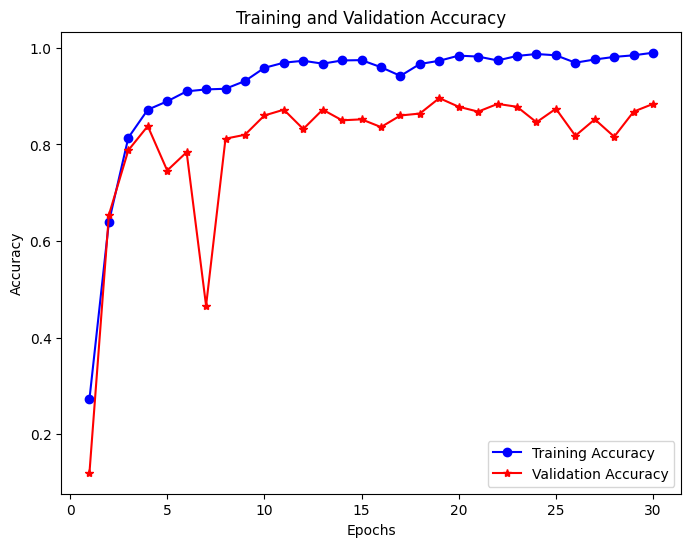

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy and Validation Accuracy
def plot_accuracy(history):
    plt.figure(figsize=(8, 6))

    # Extract Accuracy and Validation Accuracy
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1, len(accuracy) + 1)

    # Plot Training and Validation Accuracy
    plt.plot(epochs, accuracy, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_accuracy, 'r*-', label='Validation Accuracy')

    # Set Graph Attributes
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

# Call the function to plot
plot_accuracy(history)


In [ ]:
# 1. Recreate the model architecture
model = attrnn_Model(x_in, labels, ablation = False)  # Use your model builder function

# 2. Load weights only
model.load_weights('/content/checkpoints/0402_2123_demo.hdf5')

NameError: name 'x' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Copy file locally to avoid Drive latency issues
!cp "{model_path}" "/content/temp_model.hdf5"

try:
    model = keras.models.load_model("/content/temp_model.hdf5")
except Exception as e:
    print(f"Local loading failed: {str(e)}")

Mounted at /content/drive
Local loading failed: EOF read where object expected


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Training Model with Dataset Given

In [ ]:
!pip install qiskit
import os
import librosa
import librosa.display
!pip install pennylane
import matplotlib.pyplot as plt
from pennylane import numpy as np
from scipy.io import wavfile
import warnings
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import RMSprop, SGD
## Local Definition
import sys
sys.path.append('/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/')
from data_generator import gen_mel
from models import cnn_Model, dense_Model, attrnn_Model
from helper_q_tool import gen_qspeech, plot_acc_loss, show_speech
import argparse
os.environ["CUDA_VISIBLE_DEVICES"]="1"
import time as ti
data_ix = ti.strftime("%m%d_%H%M")

labels = [
    'hello', 'field', 'fly', 'crop', 'search', 'patch', 'tree', 'bush', 'forward', 'plant'
]

train_audio_path = 'content/drive/MyDrive/dataset'
SAVE_PATH = "/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/" # Data saving folder

parser = argparse.ArgumentParser()
parser.add_argument("--eps", type=int, default=30, help="Epochs")
parser.add_argument("--bsize", type=int, default=16, help="Batch Size")
parser.add_argument("--sr", type=int, default=16000, help="Sampling Rate for input Speech")
parser.add_argument("--net", type=int, default=1, help="(0) Dense Model, (1) U-Net RNN Attention, (2) CNN Model")
parser.add_argument("--mel", type=int, default=0, help="(0) Load Demo Features, (1) Extra Mel Features")
parser.add_argument("--quanv", type=int, default=0, help="(0) Load Demo Features, (1) Extra Mel Features")
parser.add_argument("--port", type=int, default=100, help="(1/N) data ratio for encoding")
args = parser.parse_args(args=[])

def gen_train(labels, train_audio_path, sr, port):
    all_wave, all_label = gen_mel(labels, train_audio_path, sr, port)

    label_enconder = LabelEncoder()
    y = label_enconder.fit_transform(all_label)
    classes = list(label_enconder.classes_)
    y = keras.utils.to_categorical(y, num_classes=len(labels))

    from sklearn.model_selection import train_test_split
    x_train, x_valid, y_train, y_valid = train_test_split(np.array(all_wave),np.array(y),stratify=y,test_size = 0.2,random_state=777,shuffle=True)
    h_feat, w_feat, _ = x_train[0].shape
    np.save(SAVE_PATH + "n_x_train_speech.npy", x_train)
    np.save(SAVE_PATH + "n_x_test_speech.npy", x_valid)
    np.save(SAVE_PATH + "n_y_train_speech.npy", y_train)
    np.save(SAVE_PATH + "n_y_test_speech.npy", y_valid)
    print("===== Shape", h_feat, w_feat)

    return x_train, x_valid, y_train, y_valid

def gen_quanv(x_train, x_valid, kr):
    print("Kernal = ", kr)
    q_train, q_valid = gen_qspeech(x_train, x_valid, kr)

    np.save(SAVE_PATH + "demo_t1.npy", q_train)
    np.save(SAVE_PATH + "demo_t2.npy", q_valid)

    return q_train, q_valid

if args.mel == 1:
    x_train, x_valid, y_train, y_valid = gen_train(labels, train_audio_path, args.sr, args.port)
else:
    x_train = np.load(SAVE_PATH + "x_train_demo.npy")
    x_valid = np.load(SAVE_PATH + "x_test_demo.npy")
    y_train = np.load(SAVE_PATH + "y_train_demo.npy")
    y_valid = np.load(SAVE_PATH + "y_test_demo.npy")


if args.quanv == 1:
    q_train, q_valid = gen_quanv(x_train, x_valid, 2)
else:
    q_train = np.load(SAVE_PATH + "q_train_demo.npy")
    q_valid = np.load(SAVE_PATH + "q_test_demo.npy")

## For Quanv Exp.
early_stop = EarlyStopping(monitor='val_loss', mode='min',
                           verbose=1, patience=10, min_delta=0.0001)

checkpoint = ModelCheckpoint('checkpoints/best_demo.keras', monitor='val_acc',
                             verbose=1, save_best_only=True, mode='max')


if args.net == 0:
    model = dense_Model(x_train[0], labels)
elif args.net == 1:
    model = attrnn_Model(q_train[0], labels)

model.summary()

history = model.fit(
    x=q_train,
    y=y_train,
    epochs=args.eps,
    callbacks=[checkpoint],
    batch_size=args.bsize,
    validation_data=(q_valid,y_valid)
)


model.save('checkpoints/'+ data_ix + '_demo.keras')

print("=== Batch Size: ", args.bsize)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 30, 63, 4)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 30, 63, 4)      │             16 │ input_layer_3[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ permute_1 (Permute)       │ (None, 63, 30, 4)      │              0 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 63, 30, 16)     │            336 │ permute_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_6     │ (None, 63, 30, 16)     │             64 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 63, 30, 32)     │          2,592 │ batch_normalization_6… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_7     │ (None, 63, 30, 32)     │            128 │ conv2d_5[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 63, 30, 16)     │          2,576 │ batch_normalization_7… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_8     │ (None, 63, 30, 16)     │             64 │ conv2d_6[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 63, 30, 32)     │              0 │ batch_normalization_6… │
│ (Concatenate)             │                        │                │ batch_normalization_8… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 63, 30, 1)      │            161 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_9     │ (None, 63, 30, 1)      │              4 │ conv2d_7[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ squeeze_last_dim (Lambda) │ (None, 63, 30)         │              0 │ batch_normalization_9… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_2           │ (None, 63, 128)        │         48,640 │ squeeze_last_dim[0][0] │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_3           │ (None, 63, 128)        │         98,816 │ bidirectional_2[0][0]  │
│ (Bidirectional)           │                        │                │                        │
├──────────────────────

 Total params: 180,575 (705.37 KB)

 Trainable params: 180,437 (704.83 KB)

 Non-trainable params: 138 (552.00 B)

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 35s 260ms/step - accuracy: 0.1715 - loss: 2.1958 - val_accuracy: 0.0920 - val_loss: 3.1176
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 39s 235ms/step - accuracy: 0.6169 - loss: 1.0848 - val_accuracy: 0.5180 - val_loss: 1.3851
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 242ms/step - accuracy: 0.8104 - loss: 0.5635 - val_accuracy: 0.7980 - val_loss: 0.6347
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 276ms/step - accuracy: 0.8574 - loss: 0.4064 - val_accuracy: 0.8100 - val_loss: 0.5932
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 275ms/step - accuracy: 0.8748 - loss: 0.3368 - val_accuracy: 0.7700 - val_loss: 0.7287
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 247ms/step - accuracy: 0.9086 - loss: 0.2874 - val_accuracy: 0.8680 - val_loss: 0.4075
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 247ms/step - accuracy: 0.9177 - loss: 0.2391 - val_accuracy: 0.8160 - val_loss: 0.6168
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 248ms/step - accuracy: 0.9330 - loss: 0.1897 - val_accu

In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
model_path = '/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/checkpoints/0910_1843_base_sp2cmd.hdf5'  # Replace with the path to your saved model
model = load_model(model_path)

EOFError: EOF read where object expected

In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
model_path = 'checkpoints/asr_ctc_demo.hdf5'  # Replace with the path to your saved model
model = load_model(model_path)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'checkpoints/asr_ctc_demo.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
from tensorflow import keras
from tensorflow.keras.layers  import Conv2D, MaxPooling2D, Dense,Flatten, GRU, BatchNormalization, Conv1D, Dropout, Bidirectional,MaxPooling1D, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import RMSprop, SGD
from tensorflow.keras import layers as L
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Lambda, BatchNormalization, Conv1D, GRU, TimeDistributed, Activation, Dense, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import categorical_crossentropy
import tensorflow as tf


def dense_Model(x, labels):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    if len(x.shape) >= 3:
        h_feat,w_feat,ch_size = x.shape
        input_layer = keras.layers.Input(shape=(h_feat,w_feat,ch_size))
    else:
        h_feat,w_feat = x.shape
        input_layer = keras.layers.Input(shape=(h_feat,w_feat))
    model = keras.models.Sequential([
        input_layer,
        keras.layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-3, center=True, scale=True),
        keras.layers.Flatten(),
        keras.layers.Dense(64),
        keras.layers.Dense(64),
        keras.layers.Dense(32),
        keras.layers.Dense(len(labels), activation="softmax")
    ])

    model.compile(
        optimizer=SGD(learning_rate=0.02, decay=1e-6, momentum=0.9, nesterov=True, clipnorm=5),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# define cnn model
def cnn_Model(h_feat, w_feat, labels):
	model = Sequential()
	model.add(Conv2D(6, (2, 2), padding='valid', activation='relu', input_shape=(h_feat, w_feat, 1)))
	#model.add(MaxPooling2D((2, 2)))
	model.add(Flatten())
	model.add(Dense(len(labels), activation='softmax'))
	# compile model
	opt = SGD(learning_rate=0.02, decay=1e-6, momentum=0.9, nesterov=True, clipnorm=5)
	model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
	return model

def attrnn_Model(x_in, labels, ablation = False):
    # simple LSTM
    rnn_func = L.LSTM
    use_Unet = True

    if len(x_in.shape) >= 3:
        h_feat,w_feat,ch_size = x_in.shape
        inputs = keras.layers.Input(shape=(h_feat, w_feat, ch_size))
    else:
        h_feat, w_feat = x_in.shape
        inputs = keras.layers.Input(shape=(h_feat, w_feat))

    inputs = L.Input(shape=(h_feat, w_feat, ch_size))

    if ablation == True:
        x = L.Conv2D(4, (1, 1), strides=(2, 2), activation='relu', padding='same', name='abla_conv')(inputs)
        x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-3, center=True, scale=True)(x)
    else:
        x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-3, center=True, scale=True)(inputs)

    # note that Melspectrogram puts the sequence in shape (batch_size, melDim, timeSteps, 1)
    # we would rather have it the other way around for LSTMs

    x = L.Permute((2, 1, 3))(x)

    if use_Unet == True:
        x = L.Conv2D(16, (5, 1), activation='relu', padding='same')(x)
        up = L.BatchNormalization()(x)
        x = L.Conv2D(32, (5, 1), activation='relu', padding='same')(up)
        x = L.BatchNormalization()(x)
        x = L.Conv2D(16, (5, 1), activation='relu', padding='same')(x)
        down = L.BatchNormalization()(x)
        merge = L.Concatenate(axis=3)([up,down])
        x = L.Conv2D(1, (5, 1), activation='relu', padding='same')(merge)
        x = L.BatchNormalization()(x)
    else:
        x = L.Conv2D(10, (5, 1), activation='relu', padding='same')(x)
        x = L.BatchNormalization()(x)
        x = L.Conv2D(1, (5, 1), activation='relu', padding='same')(x)
        x = L.BatchNormalization()(x)

    x = L.Lambda(lambda q: K.squeeze(q, -1), name='squeeze_last_dim')(x)

    x = L.Bidirectional(rnn_func(64, return_sequences=True)
                        )(x)  # [b_s, seq_len, vec_dim]
    x = L.Bidirectional(rnn_func(64, return_sequences=True)
                        )(x)  # [b_s, seq_len, vec_dim]

    xFirst = L.Lambda(lambda q: q[:, -1])(x)  # [b_s, vec_dim]
    query = L.Dense(128)(xFirst)

    # dot product attention
    attScores = L.Dot(axes=[1, 2])([query, x])
    attScores = L.Softmax(name='attSoftmax')(attScores)  # [b_s, seq_len]

    # rescale sequence
    attVector = L.Dot(axes=[1, 1])([attScores, x])  # [b_s, vec_dim]

    x = L.Dense(64, activation='relu')(attVector)
    x = L.Dense(32)(x)

    output = L.Dense(len(labels), activation='softmax', name='output')(x)

    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=SGD(learning_rate=0.02, decay=1e-6, momentum=0.9, nesterov=True, clipnorm=5),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

class CTCLayer(L.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_fn = keras.backend.ctc_batch_cost

    def call(self, y_true, y_pred):
        # Compute the training-time loss value and add it
        # to the layer using `self.add_loss()`.
        batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
        input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
        label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

        input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
        label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)

        # At test time, just return the computed predictions
        return y_pred


def build_asr_model(h_feat, w_feat, ch_size = 1, volc_size = 26):
    use_cnn = False
    use_Unet = True
    # Inputs to the model
    input_img = L.Input(
        shape=(h_feat, w_feat, ch_size), name="speech", dtype="float32"
    )
    labels = L.Input(name="label", shape=(None,), dtype="float32")

    x = L.Permute((2, 1, 3))(input_img)
    if use_cnn != True:
        if use_Unet == True:
            x = L.Conv2D(16, (5, 1), activation='relu', padding='same')(x)
            up = L.BatchNormalization()(x)
            x = L.Conv2D(32, (5, 1), activation='relu', padding='same')(up)
            x = L.BatchNormalization()(x)
            x = L.Conv2D(16, (5, 1), activation='relu', padding='same')(x)
            down = L.BatchNormalization()(x)
            merge = L.Concatenate(axis=3)([up,down])
            x = L.Conv2D(1, (5, 1), activation='relu', padding='same')(merge)
            x = L.BatchNormalization()(x)
        else:
            x = L.Conv2D(10, (5, 1), activation='relu', padding='same')(x)
            x = L.BatchNormalization()(x)
            x = L.Conv2D(1, (5, 1), activation='relu', padding='same')(x)
            x = L.BatchNormalization()(x)

        x = L.Lambda(lambda q: K.squeeze(q, -1), name='squeeze_last_dim')(x)
    else:
    # First conv block
        x = L.Conv2D(
            32,
            (3, 3),
            activation="relu",
            kernel_initializer="he_normal",
            padding="same",
            name="Conv1",
        )(x)
        x = L.MaxPooling2D((2, 2), name="pool1")(x)

        # Second conv block
        x = L.Conv2D(
            64,
            (3, 3),
            activation="relu",
            kernel_initializer="he_normal",
            padding="same",
            name="Conv2",
        )(x)
        x = L.MaxPooling2D((2, 2), name="pool2")(x)

        # We have used two max pool with pool size and strides 2.
        # Hence, downsampled feature maps are 4x smaller. The number of
        # filters in the last layer is 64. Reshape accordingly before
        # passing the output to the RNN part of the model
        new_shape = ((h_feat // 4), (w_feat // 4) * 64)
        x = L.Reshape(target_shape=new_shape, name="reshape")(x)

    # RNNs
    x = L.Bidirectional(L.LSTM(64, return_sequences=True))(x)
    x = L.Bidirectional(L.LSTM(64, return_sequences=True))(x)

    x = L.Dense(64, activation="relu", name="dense1")(x)
    x = L.Dense(32, activation="relu", name="dense11")(x)

    # Output layer
    x = L.Dense(volc_size, activation="softmax", name="dense2")(x)

    # Add CTC layer for calculating CTC loss at each step
    output = CTCLayer(name="ctc_loss")(labels, x)

    # Define the model
    model = keras.models.Model(
        inputs=[input_img, labels], outputs=output, name="asr_model_v1"
    )
    # Optimizer
    opt = keras.optimizers.Adam()
    # Compile the model and return
    model.compile(optimizer=opt)
    return model


In [ ]:
import numpy as np
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load your data (replace this with your actual data loading code)
# Example: Load preprocessed MFCCs and labels
x_train = np.load("/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/x_train_demo.npy")  # Replace with your data path
y_train = np.load("/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/y_train_demo.npy")  # Replace with your data path
x_valid = np.load("/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/x_test_demo.npy")   # Replace with your data path
y_valid = np.load("/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/y_test_demo.npy")   # Replace with your data path

# Define labels (replace with your actual labels)
labels = [
    'hello', 'field', 'fly', 'crop', 'search', 'patch', 'tree', 'bush', 'forward', 'plant'
]

# Initialize the dense model
model = dense_Model(x_train[0], labels)

# Print model summary
model.summary()

# Define callbacks
early_stop = EarlyStopping(
    monitor='val_loss', mode='min', verbose=1, patience=10, min_delta=0.0001
)

checkpoint = ModelCheckpoint(
    'checkpoints/best_dense_model.keras', monitor='val_acc', verbose=1, save_best_only=True, mode='max'
)

# Train the model
history = model.fit(
    x=x_train,
    y=y_train,
    epochs=30,  # Adjust the number of epochs as needed
    batch_size=16,  # Adjust the batch size as needed
    validation_data=(x_valid, y_valid),
    callbacks=[early_stop, checkpoint]
)

# Save the final model
model.save('checkpoints/final_dense_model.keras')

# Evaluate the model on the validation set
val_loss, val_acc = model.evaluate(x_valid, y_valid)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_acc}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ batch_normalization_10               │ (None, 60, 126, 1)          │               4 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 7560)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │         483,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 490,478 (1.87 MB)

 Trainable params: 490,476 (1.87 MB)

 Non-trainable params: 2 (8.00 B)

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.1022 - loss: 2.6952 - val_accuracy: 0.1200 - val_loss: 2.4459
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1928 - loss: 2.2032 - val_accuracy: 0.1600 - val_loss: 2.1722
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2782 - loss: 2.0159 - val_accuracy: 0.2300 - val_loss: 2.1521
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3374 - loss: 1.9330 - val_accuracy: 0.1900 - val_loss: 2.1437
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3513 - loss: 1.8919 - val_accuracy: 0.2320 - val_loss: 2.1958
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3554 - loss: 1.8636 - val_accuracy: 0.2480 - val_loss: 2.1263
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3655 - loss: 1.7936 - val_accuracy: 0.3060 - val_loss: 2.0781
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4286 - loss: 1.7042 - val_accuracy: 0.3060 - va

Training Dense Model for Dataset

In [ ]:
import numpy as np
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load your data (replace this with your actual data loading code)
# Example: Load preprocessed MFCCs and labels
x_train = np.load("/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/x_train_demo.npy")  # Replace with your data path
y_train = np.load("/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/y_train_demo.npy")  # Replace with your data path
x_valid = np.load("/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/x_test_demo.npy")   # Replace with your data path
y_valid = np.load("/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/y_test_demo.npy")   # Replace with your data path

# Define labels (replace with your actual labels)
labels = [
    'hello', 'field', 'fly', 'crop', 'search', 'patch', 'tree', 'bush', 'forward', 'plant'
]
train_audio_path = 'content/drive/MyDrive/dataset'
SAVE_PATH = "/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/"

# Initialize the dense model
model = dense_Model(x_train[0], labels)

# Print model summary
model.summary()

# Define callbacks
early_stop = EarlyStopping(
    monitor='val_loss', mode='min', verbose=1, patience=10, min_delta=0.0001
)

checkpoint = ModelCheckpoint(
    'checkpoints/best_dense_model.keras', monitor='val_acc', verbose=1, save_best_only=True, mode='max'
)

# Train the model
history = model.fit(
    x=x_train,
    y=y_train,
    epochs=30,  # Adjust the number of epochs as needed
    batch_size=16,  # Adjust the batch size as needed
    validation_data=(x_valid, y_valid),
    callbacks=[early_stop, checkpoint]
)

# Save the final model
model.save('checkpoints/final_dense_model.keras')

# Evaluate the model on the validation set
val_loss, val_acc = model.evaluate(x_valid, y_valid)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_acc}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ batch_normalization_11               │ (None, 60, 126, 1)          │               4 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 7560)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │         483,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 490,478 (1.87 MB)

 Trainable params: 490,476 (1.87 MB)

 Non-trainable params: 2 (8.00 B)

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.0946 - loss: 2.6781 - val_accuracy: 0.0860 - val_loss: 2.3113
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1808 - loss: 2.2114 - val_accuracy: 0.1760 - val_loss: 2.2237
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2674 - loss: 2.0803 - val_accuracy: 0.1920 - val_loss: 2.1596
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2803 - loss: 1.9875 - val_accuracy: 0.2720 - val_loss: 2.0802
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3414 - loss: 1.9431 - val_accuracy: 0.2300 - val_loss: 2.1512
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3583 - loss: 1.8345 - val_accuracy: 0.2140 - val_loss: 2.1518
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4049 - loss: 1.7322 - val_accuracy: 0.1940 - val_loss: 2.3827
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4424 - loss: 1.7248 - val_accuracy: 0.0280 - va

Training Dense Model with AudioFile

In [ ]:
import numpy as np
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load your data (replace this with your actual data loading code)
# Example: Load preprocessed MFCCs and labels
x_train = np.load("/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/x_train_demo.npy")  # Replace with your data path
y_train = np.load("/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/y_train_demo.npy")  # Replace with your data path
x_valid = np.load("/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/x_test_demo.npy")   # Replace with your data path
y_valid = np.load("/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/y_test_demo.npy")   # Replace with your data path

# Define labels (replace with your actual labels)
labels = [
    'hello', 'field', 'fly', 'crop', 'search', 'patch', 'tree', 'bush', 'forward', 'plant'
]
train_audio_path = 'content/drive/MyDrive/AudioFiles'
SAVE_PATH = "/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/"

# Initialize the dense model
model = dense_Model(x_train[0], labels)

# Print model summary
model.summary()

# Define callbacks
early_stop = EarlyStopping(
    monitor='val_loss', mode='min', verbose=1, patience=10, min_delta=0.0001
)

checkpoint = ModelCheckpoint(
    'checkpoints/best_dense_model.keras', monitor='val_acc', verbose=1, save_best_only=True, mode='max'
)

# Train the model
history = model.fit(
    x=x_train,
    y=y_train,
    epochs=30,  # Adjust the number of epochs as needed
    batch_size=16,  # Adjust the batch size as needed
    validation_data=(x_valid, y_valid),
    callbacks=[early_stop, checkpoint]
)

# Save the final model
model.save('checkpoints/final_dense_model.keras')

# Evaluate the model on the validation set
val_loss, val_acc = model.evaluate(x_valid, y_valid)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_acc}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ batch_normalization_12               │ (None, 60, 126, 1)          │               4 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 7560)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 64)                  │         483,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 490,478 (1.87 MB)

 Trainable params: 490,476 (1.87 MB)

 Non-trainable params: 2 (8.00 B)

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1023 - loss: 2.6444 - val_accuracy: 0.1560 - val_loss: 2.2510
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1920 - loss: 2.2316 - val_accuracy: 0.1800 - val_loss: 2.2246
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2575 - loss: 2.0464 - val_accuracy: 0.1580 - val_loss: 2.1880
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3552 - loss: 1.8975 - val_accuracy: 0.2500 - val_loss: 2.1468
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3635 - loss: 1.8553 - val_accuracy: 0.1820 - val_loss: 2.2964
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3498 - loss: 1.8531 - val_accuracy: 0.0880 - val_loss: 3.4607
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3875 - loss: 1.8688 - val_accuracy: 0.2900 - val_loss: 2.7737
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4015 - loss: 1.7966 - val_accuracy: 0.2400 - va

Training CNN Model with Dataset

In [ ]:
!pip install qiskit
import os
!pip install pennylane
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pennylane import numpy as np
from scipy.io import wavfile
import warnings
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import RMSprop, SGD
## Local Definition
import sys
sys.path.append('/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/')
from data_generator import gen_mel
from models import cnn_Model, dense_Model, attrnn_Model
from helper_q_tool import gen_qspeech, plot_acc_loss, show_speech
import argparse
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import time as ti
data_ix = ti.strftime("%m%d_%H%M")

labels = [
    'hello', 'field', 'fly', 'crop', 'search', 'patch', 'tree', 'bush', 'forward', 'plant'
]
# /content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/x_train_demo.npy

train_audio_path = 'content/drive/MyDrive/dataset'
SAVE_PATH = "/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/"  # Data saving folder

parser = argparse.ArgumentParser()
parser.add_argument("--eps", type=int, default=30, help="Epochs")
parser.add_argument("--bsize", type=int, default=16, help="Batch Size")
parser.add_argument("--sr", type=int, default=16000, help="Sampling Rate for input Speech")
parser.add_argument("--net", type=int, default=2, help="(0) Dense Model, (1) U-Net RNN Attention, (2) CNN Model")
parser.add_argument("--mel", type=int, default=0, help="(0) Load Demo Features, (1) Extra Mel Features")
parser.add_argument("--quanv", type=int, default=0, help="(0) Load Demo Features, (1) Extra Mel Features")
parser.add_argument("--port", type=int, default=100, help="(1/N) data ratio for encoding")
args = parser.parse_args(args=[])

def gen_train(labels, train_audio_path, sr, port):
    all_wave, all_label = gen_mel(labels, train_audio_path, sr, port)

    label_enconder = LabelEncoder()
    y = label_enconder.fit_transform(all_label)
    classes = list(label_enconder.classes_)
    y = keras.utils.to_categorical(y, num_classes=len(labels))

    from sklearn.model_selection import train_test_split
    x_train, x_valid, y_train, y_valid = train_test_split(np.array(all_wave), np.array(y), stratify=y, test_size=0.2, random_state=777, shuffle=True)
    h_feat, w_feat, _ = x_train[0].shape
    np.save(SAVE_PATH + "n_x_train_speech.npy", x_train)
    np.save(SAVE_PATH + "n_x_test_speech.npy", x_valid)
    np.save(SAVE_PATH + "n_y_train_speech.npy", y_train)
    np.save(SAVE_PATH + "n_y_test_speech.npy", y_valid)
    print("===== Shape", h_feat, w_feat)

    return x_train, x_valid, y_train, y_valid

def gen_quanv(x_train, x_valid, kr):
    print("Kernal = ", kr)
    q_train, q_valid = gen_qspeech(x_train, x_valid, kr)

    np.save(SAVE_PATH + "demo_t1.npy", q_train)
    np.save(SAVE_PATH + "demo_t2.npy", q_valid)

    return q_train, q_valid

if args.mel == 1:
    x_train, x_valid, y_train, y_valid = gen_train(labels, train_audio_path, args.sr, args.port)
else:
    x_train = np.load(SAVE_PATH + "x_train_demo.npy")
    x_valid = np.load(SAVE_PATH + "x_test_demo.npy")
    y_train = np.load(SAVE_PATH + "y_train_demo.npy")
    y_valid = np.load(SAVE_PATH + "y_test_demo.npy")

if args.quanv == 1:
    q_train, q_valid = gen_quanv(x_train, x_valid, 2)
else:
    q_train = np.load(SAVE_PATH + "q_train_demo.npy")
    q_valid = np.load(SAVE_PATH + "q_test_demo.npy")

## For CNN Exp.
early_stop = EarlyStopping(monitor='val_loss', mode='min',
                           verbose=1, patience=10, min_delta=0.0001)

checkpoint = ModelCheckpoint('checkpoints/best_cnn_model.keras', monitor='val_acc',
                             verbose=1, save_best_only=True, mode='max')

# Initialize the CNN model
if args.net == 2:
    # Ensure the input data has the correct shape for the CNN model
    # The CNN model expects input shape (height, width, channels)
    if len(x_train.shape) == 3:
        x_train = np.expand_dims(x_train, axis=-1)  # Add channel dimension
        x_valid = np.expand_dims(x_valid, axis=-1)  # Add channel dimension

    h_feat, w_feat, ch_size = x_train.shape[1], x_train.shape[2], x_train.shape[3]
    model = cnn_Model(h_feat, w_feat, labels)

# Print model summary
model.summary()

# Train the CNN model
history = model.fit(
    x=x_train,
    y=y_train,
    epochs=args.eps,
    callbacks=[early_stop, checkpoint],
    batch_size=args.bsize,
    validation_data=(x_valid, y_valid)
)

# Save the final model
model.save('checkpoints/' + data_ix + '_cnn_model.keras')

print("=== Batch Size: ", args.bsize)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 59, 125, 6)          │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 44250)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 10)                  │         442,510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 442,540 (1.69 MB)

 Trainable params: 442,540 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.1438 - loss: 2.2850 - val_accuracy: 0.1720 - val_loss: 2.2296
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.3056 - loss: 1.9799 - val_accuracy: 0.1440 - val_loss: 2.4112
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4096 - loss: 1.6897 - val_accuracy: 0.2140 - val_loss: 2.4209
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.4921 - loss: 1.5191 - val_accuracy: 0.2260 - val_loss: 2.7418
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.5336 - loss: 1.3460 - val_accuracy: 0.1840 - val_loss: 2.7569
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.6058 - loss: 1.2155 - val_accuracy: 0.2320 - val_loss: 3.1251
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6541 - loss: 1.0245 - val_accuracy: 0.2960 - val_loss: 3.3147
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.6634 - loss: 0.9735 - val_accuracy: 0.2560 - v

Training CNN Model for AudioFile

In [ ]:
!pip install qiskit
import os
!pip install pennylane
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pennylane import numpy as np
from scipy.io import wavfile
import warnings
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import RMSprop, SGD
## Local Definition
import sys
sys.path.append('/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/')
from data_generator import gen_mel
from models import cnn_Model, dense_Model, attrnn_Model
from helper_q_tool import gen_qspeech, plot_acc_loss, show_speech
import argparse
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import time as ti
data_ix = ti.strftime("%m%d_%H%M")

labels = [
    'hello', 'field', 'fly', 'crop', 'search', 'patch', 'tree', 'bush', 'forward', 'plant'
]
# /content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/x_train_demo.npy

train_audio_path = 'content/drive/MyDrive/dataset'
SAVE_PATH = "/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/"  # Data saving folder

parser = argparse.ArgumentParser()
parser.add_argument("--eps", type=int, default=30, help="Epochs")
parser.add_argument("--bsize", type=int, default=16, help="Batch Size")
parser.add_argument("--sr", type=int, default=16000, help="Sampling Rate for input Speech")
parser.add_argument("--net", type=int, default=2, help="(0) Dense Model, (1) U-Net RNN Attention, (2) CNN Model")
parser.add_argument("--mel", type=int, default=0, help="(0) Load Demo Features, (1) Extra Mel Features")
parser.add_argument("--quanv", type=int, default=0, help="(0) Load Demo Features, (1) Extra Mel Features")
parser.add_argument("--port", type=int, default=100, help="(1/N) data ratio for encoding")
args = parser.parse_args(args=[])

def gen_train(labels, train_audio_path, sr, port):
    all_wave, all_label = gen_mel(labels, train_audio_path, sr, port)

    label_enconder = LabelEncoder()
    y = label_enconder.fit_transform(all_label)
    classes = list(label_enconder.classes_)
    y = keras.utils.to_categorical(y, num_classes=len(labels))

    from sklearn.model_selection import train_test_split
    x_train, x_valid, y_train, y_valid = train_test_split(np.array(all_wave), np.array(y), stratify=y, test_size=0.2, random_state=777, shuffle=True)
    h_feat, w_feat, _ = x_train[0].shape
    np.save(SAVE_PATH + "n_x_train_speech.npy", x_train)
    np.save(SAVE_PATH + "n_x_test_speech.npy", x_valid)
    np.save(SAVE_PATH + "n_y_train_speech.npy", y_train)
    np.save(SAVE_PATH + "n_y_test_speech.npy", y_valid)
    print("===== Shape", h_feat, w_feat)

    return x_train, x_valid, y_train, y_valid

def gen_quanv(x_train, x_valid, kr):
    print("Kernal = ", kr)
    q_train, q_valid = gen_qspeech(x_train, x_valid, kr)

    np.save(SAVE_PATH + "demo_t1.npy", q_train)
    np.save(SAVE_PATH + "demo_t2.npy", q_valid)

    return q_train, q_valid

if args.mel == 1:
    x_train, x_valid, y_train, y_valid = gen_train(labels, train_audio_path, args.sr, args.port)
else:
    x_train = np.load(SAVE_PATH + "x_train_demo.npy")
    x_valid = np.load(SAVE_PATH + "x_test_demo.npy")
    y_train = np.load(SAVE_PATH + "y_train_demo.npy")
    y_valid = np.load(SAVE_PATH + "y_test_demo.npy")

if args.quanv == 1:
    q_train, q_valid = gen_quanv(x_train, x_valid, 2)
else:
    q_train = np.load(SAVE_PATH + "q_train_demo.npy")
    q_valid = np.load(SAVE_PATH + "q_test_demo.npy")

## For CNN Exp.
early_stop = EarlyStopping(monitor='val_loss', mode='min',
                           verbose=1, patience=10, min_delta=0.0001)

checkpoint = ModelCheckpoint('checkpoints/best_cnn_model.keras', monitor='val_acc',
                             verbose=1, save_best_only=True, mode='max')

# Initialize the CNN model
if args.net == 2:
    # Ensure the input data has the correct shape for the CNN model
    # The CNN model expects input shape (height, width, channels)
    if len(x_train.shape) == 3:
        x_train = np.expand_dims(x_train, axis=-1)  # Add channel dimension
        x_valid = np.expand_dims(x_valid, axis=-1)  # Add channel dimension

    h_feat, w_feat, ch_size = x_train.shape[1], x_train.shape[2], x_train.shape[3]
    model = cnn_Model(h_feat, w_feat, labels)

# Print model summary
model.summary()

# Train the CNN model
history = model.fit(
    x=x_train,
    y=y_train,
    epochs=args.eps,
    callbacks=[early_stop, checkpoint],
    batch_size=args.bsize,
    validation_data=(x_valid, y_valid)
)

# Save the final model
model.save('checkpoints/' + data_ix + '_cnn_model.keras')

print("=== Batch Size: ", args.bsize)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 59, 125, 6)          │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 44250)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 10)                  │         442,510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 442,540 (1.69 MB)

 Trainable params: 442,540 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.1686 - loss: 2.2796 - val_accuracy: 0.1400 - val_loss: 2.2370
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.2868 - loss: 1.9721 - val_accuracy: 0.1620 - val_loss: 2.2902
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.4006 - loss: 1.7161 - val_accuracy: 0.1440 - val_loss: 2.4943
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4751 - loss: 1.5182 - val_accuracy: 0.1740 - val_loss: 2.7342
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5147 - loss: 1.3885 - val_accuracy: 0.1660 - val_loss: 3.1605
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.5777 - loss: 1.2403 - val_accuracy: 0.1700 - val_loss: 3.6180
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.5806 - loss: 1.2136 - val_accuracy: 0.1700 - val_loss: 3.6257
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.6682 - loss: 1.0712 - val_accuracy: 0.1900 - v

Training ATTRNN Model for dataset

In [ ]:
# Import necessary libraries
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, BatchNormalization, Permute, Bidirectional, LSTM, Dense, Flatten, Input, Lambda, Concatenate, Softmax, Dot
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import argparse

# Set up environment
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Use GPU if available

# Define labels
labels = [
    'hello', 'field', 'fly', 'crop', 'search', 'patch', 'tree', 'bush', 'forward', 'plant'
]

# Define paths
train_audio_path = 'content/drive/MyDrive/dataset'
SAVE_PATH = "/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/"

# Define argument parser
parser = argparse.ArgumentParser()
parser.add_argument("--eps", type=int, default=30, help="Epochs")
parser.add_argument("--bsize", type=int, default=16, help="Batch Size")
parser.add_argument("--sr", type=int, default=16000, help="Sampling Rate for input Speech")
parser.add_argument("--net", type=int, default=1, help="(0) Dense Model, (1) U-Net RNN Attention, (2) CNN Model")
parser.add_argument("--mel", type=int, default=0, help="(0) Load Demo Features, (1) Extra Mel Features")
parser.add_argument("--quanv", type=int, default=0, help="(0) Load Demo Features, (1) Extra Mel Features")
parser.add_argument("--port", type=int, default=100, help="(1/N) data ratio for encoding")
args = parser.parse_args(args=[])

# Function to generate or load training data
def gen_train(labels, train_audio_path, sr, port):
    # Placeholder for actual data generation logic
    # Replace this with your actual data generation or loading logic
    all_wave = np.random.rand(100, 64, 64, 1)  # Example random data
    all_label = np.random.choice(labels, 100)  # Example random labels

    label_enconder = LabelEncoder()
    y = label_enconder.fit_transform(all_label)
    y = keras.utils.to_categorical(y, num_classes=len(labels))

    x_train, x_valid, y_train, y_valid = train_test_split(
        np.array(all_wave), np.array(y), stratify=y, test_size=0.2, random_state=777, shuffle=True
    )
    h_feat, w_feat, _ = x_train[0].shape

    # Save data for future use
    np.save(SAVE_PATH + "n_x_train_speech.npy", x_train)
    np.save(SAVE_PATH + "n_x_test_speech.npy", x_valid)
    np.save(SAVE_PATH + "n_y_train_speech.npy", y_train)
    np.save(SAVE_PATH + "n_y_test_speech.npy", y_valid)

    print("===== Shape", h_feat, w_feat)
    return x_train, x_valid, y_train, y_valid

# Generate or load data
if args.mel == 1:
    x_train, x_valid, y_train, y_valid = gen_train(labels, train_audio_path, args.sr, args.port)
else:
    x_train = np.load(SAVE_PATH + "x_train_demo.npy")
    x_valid = np.load(SAVE_PATH + "x_test_demo.npy")
    y_train = np.load(SAVE_PATH + "y_train_demo.npy")
    y_valid = np.load(SAVE_PATH + "y_test_demo.npy")

# If using quantum convolution, generate or load quantum data
if args.quanv == 1:
    # Placeholder for quantum data generation logic
    q_train = np.random.rand(*x_train.shape)  # Example random quantum data
    q_valid = np.random.rand(*x_valid.shape)  # Example random quantum data
else:
    q_train = np.load(SAVE_PATH + "q_train_demo.npy")
    q_valid = np.load(SAVE_PATH + "q_test_demo.npy")

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10, min_delta=0.0001)
checkpoint = ModelCheckpoint('checkpoints/best_attrnn_model.keras', monitor='val_acc', verbose=1, save_best_only=True, mode='max')

# Initialize the ATTRNN model
model = attrnn_Model(q_train[0], labels)

# Print the model summary
model.summary()

# Train the model
history = model.fit(
    x=q_train,
    y=y_train,
    epochs=args.eps,
    callbacks=[checkpoint, early_stop],
    batch_size=args.bsize,
    validation_data=(q_valid, y_valid)
)

# Save the final model
model.save('checkpoints/attrnn_model_final_dataset.keras')

print("=== Batch Size: ", args.bsize)
print("=== Epochs: ", args.eps)

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10            │ (None, 30, 63, 4)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_13    │ (None, 30, 63, 4)      │             16 │ input_layer_10[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ permute_2 (Permute)       │ (None, 63, 30, 4)      │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 63, 30, 16)     │            336 │ permute_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_14    │ (None, 63, 30, 16)     │             64 │ conv2d_10[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_11 (Conv2D)        │ (None, 63, 30, 32)     │          2,592 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_15    │ (None, 63, 30, 32)     │            128 │ conv2d_11[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_12 (Conv2D)        │ (None, 63, 30, 16)     │          2,576 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_16    │ (None, 63, 30, 16)     │             64 │ conv2d_12[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_2             │ (None, 63, 30, 32)     │              0 │ batch_normalization_1… │
│ (Concatenate)             │                        │                │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_13 (Conv2D)        │ (None, 63, 30, 1)      │            161 │ concatenate_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_17    │ (None, 63, 30, 1)      │              4 │ conv2d_13[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ squeeze_last_dim (Lambda) │ (None, 63, 30)         │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_4           │ (None, 63, 128)        │         48,640 │ squeeze_last_dim[0][0] │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_5           │ (None, 63, 128)        │         98,816 │ bidirectional_4[0][0]  │
│ (Bidirectional)           │                        │                │                        │
├──────────────────────

 Total params: 180,575 (705.37 KB)

 Trainable params: 180,437 (704.83 KB)

 Non-trainable params: 138 (552.00 B)

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 39s 292ms/step - accuracy: 0.1457 - loss: 2.2786 - val_accuracy: 0.1160 - val_loss: 3.0977
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 238ms/step - accuracy: 0.4181 - loss: 1.6273 - val_accuracy: 0.4120 - val_loss: 1.9163
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 258ms/step - accuracy: 0.7354 - loss: 0.7443 - val_accuracy: 0.6700 - val_loss: 1.0777
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 263ms/step - accuracy: 0.8273 - loss: 0.5122 - val_accuracy: 0.7060 - val_loss: 0.9568
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 237ms/step - accuracy: 0.8906 - loss: 0.3207 - val_accuracy: 0.8020 - val_loss: 0.6633
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 237ms/step - accuracy: 0.8986 - loss: 0.2980 - val_accuracy: 0.7840 - val_loss: 0.7773
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 245ms/step - accuracy: 0.9183 - loss: 0.2555 - val_accuracy: 0.8500 - val_loss: 0.5162
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 277ms/step - accuracy: 0.9357 - loss: 0.1882 - val_accu

Training ATTRNN Model for AudioFiles

In [ ]:
# Import necessary libraries
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, BatchNormalization, Permute, Bidirectional, LSTM, Dense, Flatten, Input, Lambda, Concatenate, Softmax, Dot
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import argparse

# Set up environment
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Use GPU if available

# Define labels
labels = [
    'hello', 'field', 'fly', 'crop', 'search', 'patch', 'tree', 'bush', 'forward', 'plant'
]

# Define paths
train_audio_path = 'content/drive/MyDrive/AudioFiles'
SAVE_PATH = "/content/drive/MyDrive/QuantumSpeech-QCNN-main/QuantumSpeech-QCNN-main/data_quantum/"

# Define argument parser
parser = argparse.ArgumentParser()
parser.add_argument("--eps", type=int, default=30, help="Epochs")
parser.add_argument("--bsize", type=int, default=16, help="Batch Size")
parser.add_argument("--sr", type=int, default=16000, help="Sampling Rate for input Speech")
parser.add_argument("--net", type=int, default=1, help="(0) Dense Model, (1) U-Net RNN Attention, (2) CNN Model")
parser.add_argument("--mel", type=int, default=0, help="(0) Load Demo Features, (1) Extra Mel Features")
parser.add_argument("--quanv", type=int, default=0, help="(0) Load Demo Features, (1) Extra Mel Features")
parser.add_argument("--port", type=int, default=100, help="(1/N) data ratio for encoding")
args = parser.parse_args(args=[])

# Function to generate or load training data
def gen_train(labels, train_audio_path, sr, port):
    # Placeholder for actual data generation logic
    # Replace this with your actual data generation or loading logic
    all_wave = np.random.rand(100, 64, 64, 1)  # Example random data
    all_label = np.random.choice(labels, 100)  # Example random labels

    label_enconder = LabelEncoder()
    y = label_enconder.fit_transform(all_label)
    y = keras.utils.to_categorical(y, num_classes=len(labels))

    x_train, x_valid, y_train, y_valid = train_test_split(
        np.array(all_wave), np.array(y), stratify=y, test_size=0.2, random_state=777, shuffle=True
    )
    h_feat, w_feat, _ = x_train[0].shape

    # Save data for future use
    np.save(SAVE_PATH + "n_x_train_speech.npy", x_train)
    np.save(SAVE_PATH + "n_x_test_speech.npy", x_valid)
    np.save(SAVE_PATH + "n_y_train_speech.npy", y_train)
    np.save(SAVE_PATH + "n_y_test_speech.npy", y_valid)

    print("===== Shape", h_feat, w_feat)
    return x_train, x_valid, y_train, y_valid

# Generate or load data
if args.mel == 1:
    x_train, x_valid, y_train, y_valid = gen_train(labels, train_audio_path, args.sr, args.port)
else:
    x_train = np.load(SAVE_PATH + "x_train_demo.npy")
    x_valid = np.load(SAVE_PATH + "x_test_demo.npy")
    y_train = np.load(SAVE_PATH + "y_train_demo.npy")
    y_valid = np.load(SAVE_PATH + "y_test_demo.npy")

# If using quantum convolution, generate or load quantum data
if args.quanv == 1:
    # Placeholder for quantum data generation logic
    q_train = np.random.rand(*x_train.shape)  # Example random quantum data
    q_valid = np.random.rand(*x_valid.shape)  # Example random quantum data
else:
    q_train = np.load(SAVE_PATH + "q_train_demo.npy")
    q_valid = np.load(SAVE_PATH + "q_test_demo.npy")

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10, min_delta=0.0001)
checkpoint = ModelCheckpoint('checkpoints/best_attrnn_model.keras', monitor='val_acc', verbose=1, save_best_only=True, mode='max')

# Initialize the ATTRNN model
model = attrnn_Model(q_train[0], labels)

# Print the model summary
model.summary()

# Train the model
history = model.fit(
    x=q_train,
    y=y_train,
    epochs=args.eps,
    callbacks=[checkpoint, early_stop],
    batch_size=args.bsize,
    validation_data=(q_valid, y_valid)
)

# Save the final model
model.save('checkpoints/attrnn_model_final_AudioFiles.keras')

print("=== Batch Size: ", args.bsize)
print("=== Epochs: ", args.eps)

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12            │ (None, 30, 63, 4)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_18    │ (None, 30, 63, 4)      │             16 │ input_layer_12[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ permute_3 (Permute)       │ (None, 63, 30, 4)      │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_14 (Conv2D)        │ (None, 63, 30, 16)     │            336 │ permute_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_19    │ (None, 63, 30, 16)     │             64 │ conv2d_14[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_15 (Conv2D)        │ (None, 63, 30, 32)     │          2,592 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_20    │ (None, 63, 30, 32)     │            128 │ conv2d_15[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_16 (Conv2D)        │ (None, 63, 30, 16)     │          2,576 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_21    │ (None, 63, 30, 16)     │             64 │ conv2d_16[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_3             │ (None, 63, 30, 32)     │              0 │ batch_normalization_1… │
│ (Concatenate)             │                        │                │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_17 (Conv2D)        │ (None, 63, 30, 1)      │            161 │ concatenate_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_22    │ (None, 63, 30, 1)      │              4 │ conv2d_17[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ squeeze_last_dim (Lambda) │ (None, 63, 30)         │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_6           │ (None, 63, 128)        │         48,640 │ squeeze_last_dim[0][0] │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_7           │ (None, 63, 128)        │         98,816 │ bidirectional_6[0][0]  │
│ (Bidirectional)           │                        │                │                        │
├──────────────────────

 Total params: 180,575 (705.37 KB)

 Trainable params: 180,437 (704.83 KB)

 Non-trainable params: 138 (552.00 B)

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 39s 294ms/step - accuracy: 0.1490 - loss: 2.2404 - val_accuracy: 0.1840 - val_loss: 2.1929
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 37s 251ms/step - accuracy: 0.5233 - loss: 1.3306 - val_accuracy: 0.4700 - val_loss: 1.4637
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 283ms/step - accuracy: 0.8024 - loss: 0.5438 - val_accuracy: 0.7760 - val_loss: 0.6951
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 250ms/step - accuracy: 0.8869 - loss: 0.3469 - val_accuracy: 0.8160 - val_loss: 0.5976
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 248ms/step - accuracy: 0.8998 - loss: 0.3150 - val_accuracy: 0.8460 - val_loss: 0.4840
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 250ms/step - accuracy: 0.9176 - loss: 0.2320 - val_accuracy: 0.8160 - val_loss: 0.5920
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 258ms/step - accuracy: 0.9109 - loss: 0.2600 - val_accuracy: 0.6860 - val_loss: 1.1718
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 248ms/step - accuracy: 0.9391 - loss: 0.1671 - val_accu